# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [130]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [131]:
# Cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [132]:
# Mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [133]:
# Mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [134]:
# Mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [135]:
# Revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [136]:
# Inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [137]:
# Inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [138]:
# Inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [129]:
# Cantidad de nulos para users
print("--- Cantidad de valores nulos ---")
print(users.isnull().sum())

print("\n--- Proporción de valores nulos ---")
print(users.isnull().mean())

--- Cantidad de valores nulos ---
user_id          0
first_name       0
last_name        0
age              0
city           565
reg_date        40
plan             0
churn_date    3534
dtype: int64

--- Proporción de valores nulos ---
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.14125
reg_date      0.01000
plan          0.00000
churn_date    0.88350
dtype: float64


In [128]:
# Cantidad de nulos para usage
print("--- Cantidad de valores nulos ---")
print(usage.isnull().sum())

print("\n--- Proporción de valores nulos ---")
print(usage.isnull().mean())

--- Cantidad de valores nulos ---
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
is_text         0
is_call         0
dtype: int64

--- Proporción de valores nulos ---
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
is_text     0.00000
is_call     0.00000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
---

**Valores nulos**  

- ¿Qué columnas tienen valores faltantes y en qué proporción?
  * En users: Las columnas `city`, aprox: 11.7% y `churn_date`, aprox: 88.3% tienen datos faltantes.
    
- Indica qué harías: ¿imputar, eliminar, ignorar?
  * `users.city`: Imputar con un valor determinado "unknown", ya que cae en el rango del 5-30%.
  * `users.churn_date`: Dejar como "NaN" ya que la alta proporción de nulos significa que la mayoría de clientes siguen activos.
  * `usage.date`: Eliminar filas, ya que es menor al 5% y un registro de consumo sin fecha y esto carece de valor para el análisis.
  * `usage.duration` y `usage.length`: Imputar con "0", ya que son nulos estructurales. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [127]:
# Explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.136000
std,1154.844867,17.689919
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,48.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` funciona como un identificador secuencial. La media no aporta valor analítico pero el máximo y mínimo, confirman que el rango está dentro de los esperado, sin valores negativos 
- La columna `age` presenta un valor mínimo de -999, el cual es un "sentinel" usado para representar datos faltantes. Esto afecta las estadísticas, por lo que se requiere transformar en un "NaN" o imputarlo en la limpieza.

In [126]:
# Explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length,is_text,is_call
count,40000.00000,40000.000000,17924.000000,22104.000000,40000.000000,40000.000000
mean,20000.50000,12002.405975,5.202237,52.127398,0.552300,0.447700
std,11547.14972,1157.279564,6.842701,56.611183,0.497263,0.497263
min,1.00000,10000.000000,0.000000,0.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000,0.000000,0.000000
50%,20000.50000,12013.000000,3.500000,50.000000,1.000000,0.000000
75%,30000.25000,13005.000000,6.990000,64.000000,1.000000,1.000000
max,40000.00000,13999.000000,120.000000,1490.000000,1.000000,1.000000


- La columna `id` funciona como un identificador secuencial único para cada registro, sin comportamiento anormal.
- La columna `user_id` muestra un rango de 10000 a 13999, esto es congruente ya que coincide con los id de los clientes en la tabla de "users".   
- Las columnas `duration` y `length` tienen un valor mínimo de 0, lo que confirma que no hay sentinels negativos, sin embargo, hay valores máximos de 120 minutos en llamadas y 1490 caracteres en mensajes, y estos son valores muy altos en comparación al promedio, esto sugiere posibles "outliers". 

In [125]:
# Explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"--- Valores únicos en {col} ---")
    print(users[col].value_counts())
    print("\n")

--- Valores únicos en city ---
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


--- Valores únicos en plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64




- La columna `city` presenta 6 ciudades válidas de Colombia y México, pero contiene un "sentinel" evidente: (ciudad = ?), el cual aparece en 96 registros y deberá ser tratado como un "NaN". 
- La columna `plan` está completamente limpia y consistente, con dos categorías separadas: "Básico" y "Premium". Coinciden exactamente con el catálogo del dataset de planes.

In [124]:
# Explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` está completamente limpia, ya que cuenta con dos categorías: "text" con 22092 registros y "call" con 17908 registros. 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  * En el dataset de `users`, detecté un valor de "-999" en la columna de `age` y un símbolo de "?" en la columna categórica de `city`.
      
- ¿Qué acción tomarías?
  * Usar la función `.replace()` para convertir ambos "sentinels" en nulos reales "NaN", ya que esto es muy importante para que pandas los reconozca como datos faltantes y no alteren y modifiquen los datos. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [44]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [45]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [46]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, la mayoría de los registros se atribuyen de manera uniforma entre los años 2022, 2023, 2024. Sin embargo, existen 40 registros del año 2026, lo cual está fuera del rango establecido para el estudio de este análisis.

In [47]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, el total de las fechas válidas se concentra exclusivamente en el año 2024.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  * En la columna `reg_date` aparecen 40 registros con el año 2026. Esto es un error de captura, ya que el alcance del estudio abarca únicamente hasta el año 2024.
    
- ¿Qué harías con ellas?
  * Al tratarse de 40 filas (1% de 4000), lo ideal es transformar esos años a valores nulos "NaT".

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [48]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [49]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False).head(10))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [123]:
# Marcar fechas futuras como NA para reg_date
# Reemplazar las fechas cuyo año sea mayor a 2024 con pd.NaT (Not a Time)
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False))

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [51]:
# Verificación MAR en usage (Missing At Random) para duration
nulos_duration = usage[usage['duration'].isna()]
print("Tipos de servicio cuando 'duration' es nulo:")
print(nulos_duration['type'].value_counts())

Tipos de servicio cuando 'duration' es nulo:
text    22076
Name: type, dtype: int64


In [52]:
# Verificación MAR en usage (Missing At Random) para length
nulos_length = usage[usage['length'].isna()]
print("Tipos de servicio cuando 'length' es nulo:")
print(nulos_length['type'].value_counts())

Tipos de servicio cuando 'length' es nulo:
call    17896
Name: type, dtype: int64


Diagnóstico de nulos en `duration` y `length`: Se confirma que los valores nulos tienen un comportamiento "MAR" ya que su ausencia es predecible y depende totalmente de la categoría en la columna `type`:

*Los 22,076 nulos en `duration` pertenecen 100% a los mensajes "text", ya que no tienen duración en minutos.

*Los 17,896 nulos en `length` pertenecen 100% a las llamdas "call", ya que no se miden en longitud de caracteres.

Decisión: Se deben mantener como nulos, si se llegaran a imputar con "0", al momento de calcular métricas clave, los registros de mensajes entrarían en la ecuación con valor "cero" y sesgarían la media real hacia abajo.  

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [122]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'duration']].sum().reset_index()

# Observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [121]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# Observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [120]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')

# Observar resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [56]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [57]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

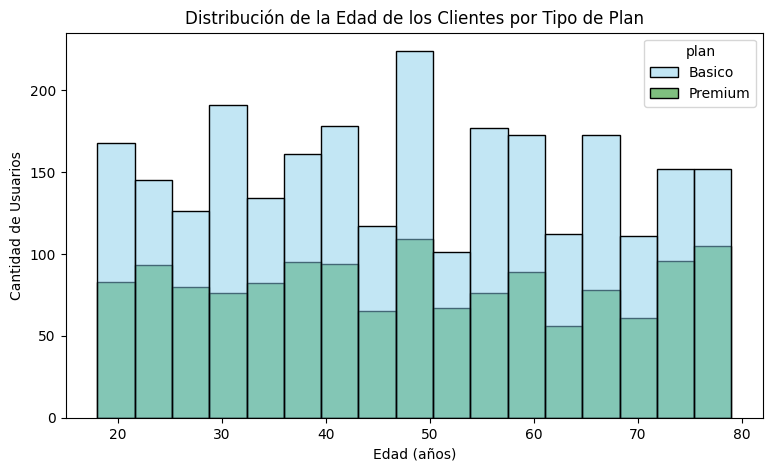

In [58]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(9, 5))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title("Distribución de la Edad de los Clientes por Tipo de Plan")
plt.xlabel("Edad (años)")
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights: 
- Distribución: Presenta una distribución simétrica y uniforme, no tiene sesgos a las orillas, por lo que indica que la empresa tiene una cantidad muy similar de usuarios en todos los rangos de edad.

- Patrones por plan: Dentro de todos los rangos, hay una mayor proporción de usuarios con el plan "Básico", con lo que empata con el 64%.8 de dominancia. No existe un patrón en donde los jóvenes o adultos mayores prefieran un plan sobre otro.

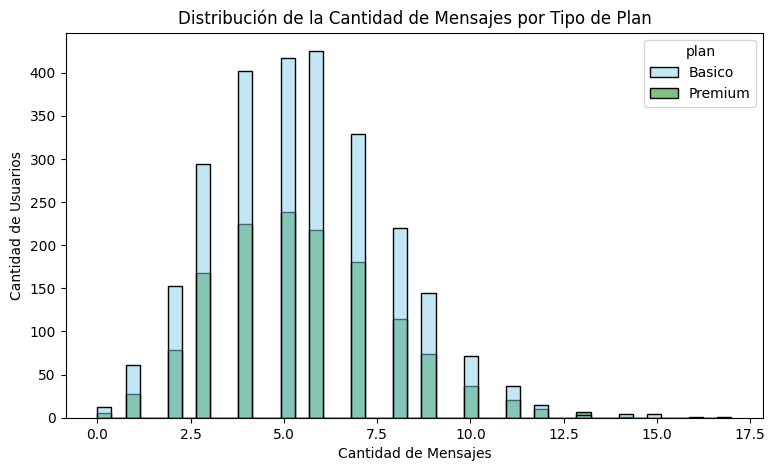

In [59]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(9, 5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title("Distribución de la Cantidad de Mensajes por Tipo de Plan")
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights: 
- Distribución: La distribución de los mensajes tiene una forma de campana, pero está ligeramente sesgada a la derecha, ya que la gran mayoría de los usuarios, envían entre 3 y 8 mensajes, con un pico muy notable entre los 5 y 6 mensajes de texto.

- Patrones por plan: Los usuarios de ambos planes, presentan exactamente el mismo comportamiento de uso; la proporción de planes "Básicos" (color azul cielo), es mayor gracias a que hay más clientes en total, pero la conducta de "cantidad de mensajes" es el mismo según el plan contratado.  

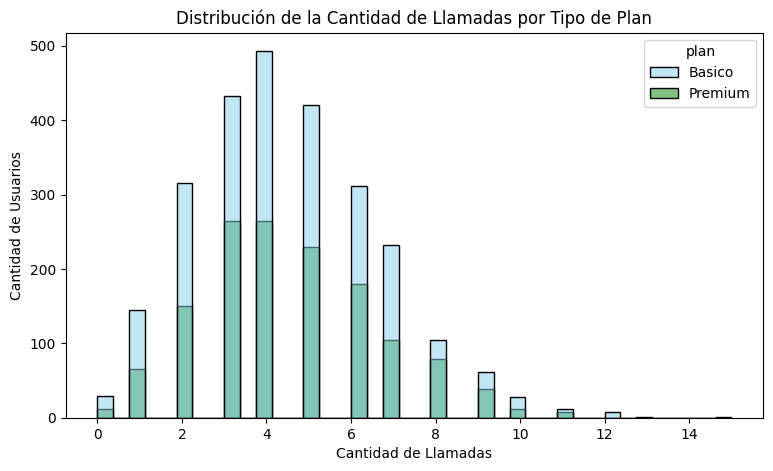

In [60]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(9, 5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title("Distribución de la Cantidad de Llamadas por Tipo de Plan")
plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights: 
- Distribución: Al igual que en caso de los mensajes, las llamadas muestran una distribución sesgada a la derecha. El volumen principal se concentra entre las 2 y 6 llamadas por usuario, desapareciendo prácticamente de 11 en adelante.

- Patrones por plan: No existe un patrón diferenciador, El plan "Premium" no parece incentivar a los usuarios a realizar un mayor número de llamada en comparación con los usuarios que manejan un plan "Básico".

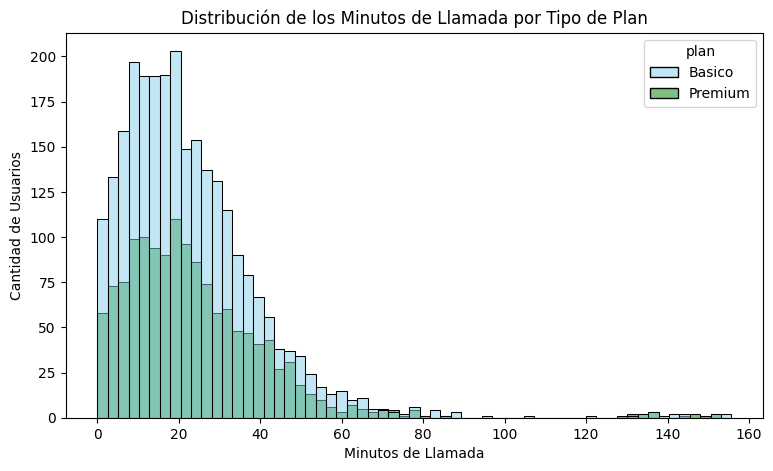

In [61]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(9, 5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title("Distribución de los Minutos de Llamada por Tipo de Plan")
plt.xlabel("Minutos de Llamada")
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights: 
- Distribución: Esta es la variable con el sesgo a la derecha más pronunciado (larga cola hacia valores altos), mientras que la inmensa mayoría de los clientes consume menos de 40 minutos, la gráfica revela visualmente un pequeño grupo aislado de usuarios atípicos (outliers) que superan los 120 y hasta 140 minutos de uso.

- Patrones por plan: El comportamiento de consumo en minutos es consistente en ambos planes. La presencia de usuarios extremos en la marca de 140 minutos, ocurre tanto en el plan "Básico" como en el "Premium".

### 5.2 Identificación de Outliers

🎯 **Objetivo:**
Detectar valores extremos en las variables clave de uso y clientes que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**

Usa boxplots para identificar visualmente outliers en las siguientes columnas:

* `age`
* `cant_mensajes`
* `cant_llamadas`
* `total_minutos_llamada`

Crea un `for` para generar los 4 boxplots automáticamente.

Después de crear los gráficos, responde si existen o no outliers en las variables.
Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el método IQR y decide qué hacer con ellos.
Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**

* Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

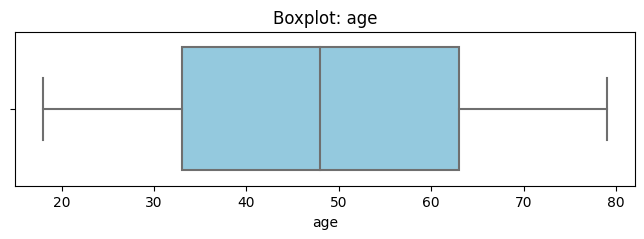

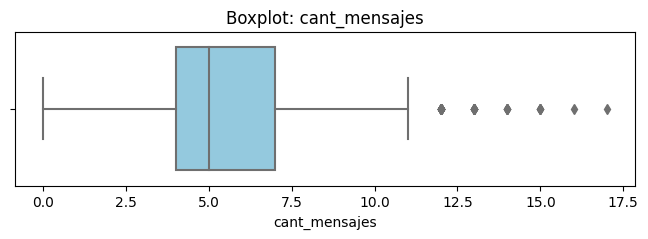

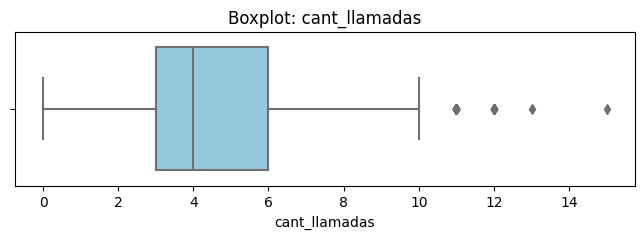

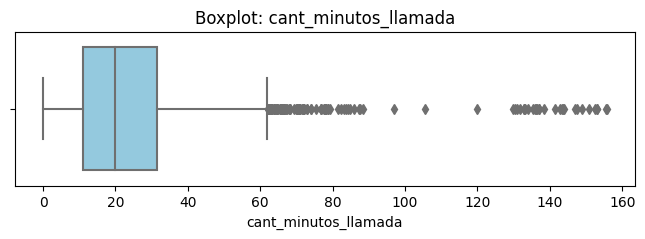

In [149]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 2)) #Un tamaño horizontal ayuda a leer mejor los boxplots
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers, los "bigotes" del gráfico abarcan toda la distribución de edades (de 18 a 79 años), sin dejar ningún punto suelto a los lados, lo que confirma que no hay edades atípicas o irreales.
- cant_mensajes: Presenta outliers, se observan puntos individuales más allá del "bigote" derecho (límite superior), indicando usuarios que envían una cantidad de mensajes significativamente mayor al usuario promedio.
- cant_llamadas: Presenta outliers, al igual que en el caso de los mensajes, hay puntos más allá del límite superior que están atribuidos por usuarios con alto volumen de llamadas.
- cant_minutos_llamada: Presenta outliers "extremos", este gráfico muestra la mayor cantidad de puntos dispersos del lado derecho del "bigote", confirmando visualmente que existen "heavy users", que superan los 120 y hasta 140 minutos.

In [114]:
# Calcular Limites con el metodo IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    # 1. Calcular Cuartil 1 (25%) y Cuartil 3 (75%)
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    
    # 2. Calcular Rango Intercuartilico (IQR)
    IQR = Q3 - Q1
    
    # 3. Calcular Limite superior
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"El limite superior para {col} es: {limite_superior}")

El limite superior para cant_mensajes es: 11.5
El limite superior para cant_llamadas es: 10.5
El limite superior para cant_minutos_llamada es: 61.8575


In [115]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantener. El límite superior estadístico es 11.5, pero existen usuarios que envían hasta 17 mensajes. Por lo que 17 mensajes en la vida cotidiana de una persona es perfectamente posible para un usuario activo. 
- cant_llamadas: Mantener. El límite superior estadístico marca 10.5 y el máximo registrado es de 15 llamadas. Estos números reflejan simplemente a usuarios con mayor necesidad de comunicación. Eliminarlos conlleva perder de vista un segmento rentable.
- cant_minutos_llamada: Mantener. Esta variable presenta la brecha más amplia (61.85 vs 155.69 minutos), lejos de ser datos erróneos, representan a los usuarios que más consumen el servicio. Excluirlos arruinaría cualquier análisis comercial y el diseño de futuros posibles planes o paquetes telefónicos. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [143]:
# Crear columna grupo_uso
import numpy as np

# 1. Definir las reglas lógicas (< 5 y < 10)
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

# 2. Definir las etiquetas para cada regla
etiquetas = ['Bajo uso', 'Uso medio']

# 3. Aplicar 'np.select' con "Alto uso" como valor por defecto (el resto de los casos)
user_profile['grupo_uso'] = np.select(condiciones, etiquetas, default='Alto uso')

In [144]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [145]:
# Crear columna grupo_edad
# 1. Definir las reglas lógicas (< 30 y < 60)
condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

# 2. Definir las etiquetas correspondientes
etiquetas_edad = ['Joven', 'Adulto']

# 3. Aplicar 'np.select' con "Adulto Mayor" como valor por defecto
user_profile['grupo_edad'] = np.select(condiciones_edad, etiquetas_edad, default='Adulto Mayor')

In [146]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor,Bajo uso


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

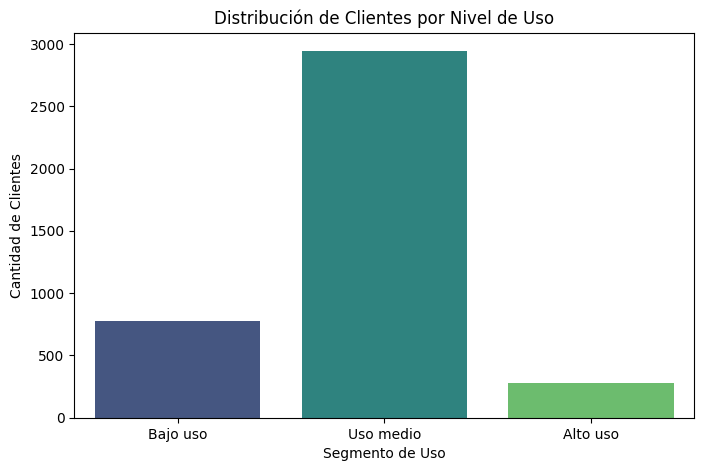

In [147]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Clientes por Nivel de Uso')
plt.xlabel('Segmento de Uso')
plt.ylabel('Cantidad de Clientes')
plt.show()

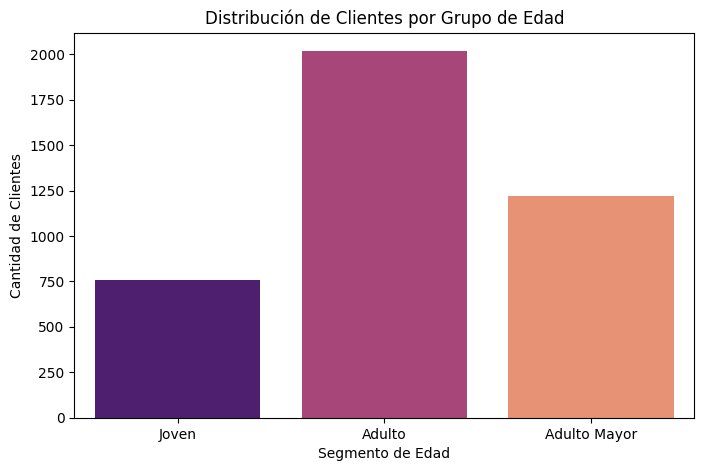

In [148]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Segmento de Edad')
plt.ylabel('Cantidad de Clientes')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### 8.1 Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

* **Valores centinela (Errores de captura):** Se detectó la edad "-999" (imputada con la mediana para no sesgar promedios) y 565 registros de ciudad con "?" (14% de la base), los cuales se marcaron como nulos verdaderos.
* **Fechas fuera de rango:** Existían 40 usuarios (1% de los datos) con un año de registro futuro imposible (2026). Se convirtieron a nulos (`NaT`) para evitar edades de antigüedad negativas.
* **Ausencias estructurales (MAR):** Se validó que el 100% de los nulos en `duration` eran mensajes, y en `length` eran llamadas. Se mantuvieron nulos para no derrumbar los promedios reales rellenándolos con ceros.

🔍 **Segmentos por Edad**

* El núcleo duro de ConnectaTel es el segmento **Adulto** (30 a 60 años), representando la inmensa mayoría de la cartera, seguido por el **Adulto Mayor**.
* El segmento **Joven** (menores de 30 años) es la minoría absoluta, revelando una nula penetración de la marca en las nuevas generaciones.

📊 **Segmentos por Nivel de Uso**

* El modelo de negocio se sostiene por un cliente de **Uso Medio**, el cual domina la cartera y mantiene un consumo predecible y estable (promedio de 4.5 llamadas y 23.3 min).
* Existe un nicho valioso de **Alto Uso (Heavy Users / Outliers)**. Aunque son pocos clientes, alcanzan máximos atípicos (hasta 15 llamadas o 155 minutos de uso), estresando más la red pero representando oportunidades clave de monetización.

➡️ **Esto sugiere que...**
La oferta actual de ConnectaTel es cómoda para un público adulto tradicional, pero el catálogo de productos está desalineado. Anteriormente descubrimos que los usuarios del plan "Premium" tienen exactamente el mismo bajo nivel de consumo que los del plan "Básico". Esto significa que el plan Premium no está incentivando un mayor uso, y los "Heavy Users" están dispersos sin un producto que realmente se adapte a sus altos niveles de demanda.

💡 **Recomendaciones**

* **Rediseñar la oferta Premium:** Dado que estadísticamente no hay diferencia de uso entre planes, se deben agregar beneficios exclusivos al plan Premium (ej. redes sociales ilimitadas, roaming internacional) para justificar su costo, retener a esos clientes y evitar que bajen al plan Básico.
* **Campaña de Captación Joven:** Lanzar un nuevo plan enfocado 100% en el segmento 'Joven' (menores de 30), con estrategias de marketing digital y beneficios que apelen a este mercado desatendido.
* **Monetización de Heavy Users (Outliers):** Diseñar paquetes de *add-ons* (minutos/mensajes extra) o un plan "Ultra" para captar el valor de los usuarios atípicos (aquellos que superan la barrera del límite IQR de 61 minutos). Alternativamente, auditar este 1% de casos extremos para descartar posibles líneas automatizadas (fraude).

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`